<a href="https://colab.research.google.com/github/MAHArishbah/VIT/blob/dev/ViT_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torchvision
import torch.nn as nn
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision.transforms import v2
from datasets import load_dataset
from PIL import Image
import wandb,os
import matplotlib.pyplot as plt
from google.colab import userdata
from google.colab import drive
import math
import random
import numpy as np

seed=42

def seed_everything(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
torch.set_float32_matmul_precision("high")   # allow TF32 tensor cores for FP32 matrix multiplications

In [2]:


train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.08, 1.0)), #Data augmentation Randomly crops a region and resizes to 224x224
    transforms.RandomHorizontalFlip(),                    #Data augmentation 50% chance to flip horizontally
    transforms.RandAugment(num_ops=2,magnitude=9),        #randomly 2 out of rotate, shear, translate, brightness, contrast, solarize, posterize and equalize
    transforms.ToTensor(),                                #changes PIL to torch tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transform= transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class HuggingFaceImageNetSubset(Dataset):                 #convert Hugging Face Dataset into standard PyTorch Tensors
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        img = item['image'].convert("RGB") if isinstance(item['image'], Image.Image) else item['image']    #Convert grayscale images to RGB if any exist
        label = item['label']

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

print("Downloading ImageNet-100 from Hugging Face...")

raw_train = load_dataset("ilee0022/ImageNet100", split="train") # Downloads subset of 100 classes instead of 1000
raw_val = load_dataset("ilee0022/ImageNet100", split="validation")
raw_test = load_dataset("ilee0022/ImageNet100", split="test")

# Wrap them up for PyTorch
train_dataset = HuggingFaceImageNetSubset(raw_train, transform=train_transform)
val_dataset = HuggingFaceImageNetSubset(raw_val, transform=val_transform)
test_dataset = HuggingFaceImageNetSubset(raw_test, transform=val_transform)



print(f"Successfully loaded {len(train_dataset)} training images across 100 classes!")


Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Successfully loaded 117000 training images across 100 classes!


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Hyperparameters
num_workers=8             #for dataloaders
num_classes = 100
num_channels = 3
img_size = 224
patch_size = 16
num_patches = (img_size // patch_size) ** 2
embedding_dim = 256
attention_heads = 8
transformer_blocks = 6
mlp_hiddennodes = 512
batch_size = 128
learning_rate = 0.0005
epochs = 50
weight_decay=0.05
warmup_epochs=5
min_lr=1e-6
grad_clip=1.0
run_name = "vit-p16-d256-L6-h8-it2-ra-ls-cm"
run_id   = "vit-it2-ra-ls-cm"
cutmix_alpha=1.0
cutmix_prob=0.5
label_smoothing=0.1
dropout=0.0

In [4]:
drive.mount('/content/drive')

ckpt_dir=f'/content/drive/MyDrive/vit-imagenet100/{run_name}'
os.makedirs(ckpt_dir, exist_ok=True)
best_path  = f"{ckpt_dir}/best.pt"
last_path  = f"{ckpt_dir}/last.pt"
final_path = f"{ckpt_dir}/final.pt"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
g=torch.Generator()
g.manual_seed(seed)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True,generator=g,persistent_workers=True,drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True,persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)


In [6]:
#patch embedding
#transsformer encoder
#MLP_head
#vision trans


In [7]:
class PatchEmbedding(nn.Module):
  def __init__(self) -> None:
    super().__init__()
    self.patch_embed=nn.Conv2d(num_channels,embedding_dim,kernel_size=patch_size,stride=patch_size)

  def forward(self,x):
    x=self.patch_embed(x)  # (B, C, H, W) = (128, 3, 224, 224) -> (B, D, H/P, W/P) = (128, 256, 14, 14)
    x=x.flatten(2).transpose(1,2) # (128, 256, 14, 14) -> flatten(2) -> (128, 256, 196) -> transpose -> (B, N, D) = (128, 196, 256) MHA expects batch first B, T,C
    return x  # 196 patch tokens per image, each a 256-dim embedding


In [8]:

class TransformerEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.layernom1=nn.LayerNorm(embedding_dim)
    self.layernorm2=nn.LayerNorm(embedding_dim)
    self.multihead_attention=nn.MultiheadAttention(embedding_dim,attention_heads,batch_first=True)
    self.attn_out_dropout=nn.Dropout(dropout)
    self.mlp=nn.Sequential(
        nn.Linear(embedding_dim,mlp_hiddennodes),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(mlp_hiddennodes,embedding_dim),
        nn.Dropout(dropout)
      )

  def forward(self,x):
    residual1=x
    x=self.layernom1(x)
    x=self.multihead_attention(x,x,x,need_weights=False)[0]
    x=self.attn_out_dropout(x)
    x=x+residual1

    residual2=x
    x=self.layernorm2(x)
    x=self.mlp(x)
    x=x+residual2

    return x



In [9]:
class Mlp_head(nn.Module):
  def __init__(self):
    super().__init__()
    self.layernorm1=nn.LayerNorm(embedding_dim)
    self.mlp_head=nn.Linear(embedding_dim,num_classes)

  def forward(self,x):
    x=self.layernorm1(x)
    x=self.mlp_head(x)

    return x

In [10]:

class VisionTransformer(nn.Module):
  def __init__(self):
    super().__init__()
    self.patch_embedding=PatchEmbedding()
    self.cls_token=nn.Parameter(torch.randn(1,1,embedding_dim))
    nn.init.trunc_normal_(self.cls_token,std=0.02)
    self.postion_embedding=nn.Parameter(torch.randn(1,num_patches+1,embedding_dim))
    nn.init.trunc_normal_(self.postion_embedding,std=0.02)
    self.pos_dropout=nn.Dropout(dropout)
    self.transformer_blocks=nn.Sequential(*[TransformerEncoder()for _ in range(transformer_blocks)])
    self.mlp_head=Mlp_head()

  def forward(self,x):
    x=self.patch_embedding(x)
    B=x.size(0)
    class_tokens=self.cls_token.expand(x.size(0),-1,-1)
    x=torch.cat((class_tokens,x),dim=1)# (128, 196, 256) -->(128, 197, 256)
    x=x+ self.postion_embedding
    x=self.pos_dropout(x)
    x=self.transformer_blocks(x)
    x=x[:,0]
    x=self.mlp_head(x)

    return x




Input: (128, 3, 224, 224). This is the image layout, as the conv expects.
self.patch_embed (the Conv2d): (128, 256, 14, 14). Each of the 14 × 14 patches now has a 256-number vector, but the patches are still arranged in a grid.
flatten(2): (128, 256, 196). The grid is unrolled into a list of 196 patches.
transpose(1, 2): (128, 196, 256). This is the sequence layout (B, T, C), with T = 196.
torch.cat with the CLS token: (128, 197, 256). One extra token goes at the front, so T = 197.
+ self.postion_embedding: (128, 197, 256). The shape doesn't change, because the (1, 197, 256) position embedding is broadcast across the batch.
The 6 transformer blocks: (128, 197, 256). Each block keeps the shape.
x[:, 0]: (128, 256). Only the CLS token is kept.
mlp_head: (128, 100). This gives the logits.

In [11]:
!nvidia-smi

Sun Sep 20 09:55:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   56C    P8             17W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
seed_everything(seed)
model=VisionTransformer().to(device)

decay,no_decay,no_decay_names=[],[],[]
for name, p in model.named_parameters():
  if p.ndim <=1 or name in ('cls_token','postion_embedding'):
    no_decay.append(p)
    no_decay_names.append(name)
  else:
    decay.append(p)
optimizer=torch.optim.AdamW(
    [{"params": decay, "weight_decay": weight_decay},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=learning_rate)

steps_per_epoch=len(train_loader)
total_steps= epochs * steps_per_epoch
warmup_steps=warmup_epochs * steps_per_epoch

def lr_lambda(step):
  if step < warmup_steps:
    return (step+1)/warmup_steps
  p =(step-warmup_steps)/max(1,total_steps-warmup_steps)
  floor=min_lr/learning_rate
  return floor + (1-floor)*0.5 * (1+math.cos(math.pi*p))
scheduler=torch.optim.lr_scheduler.LambdaLR(optimizer,lr_lambda)

lossF=nn.CrossEntropyLoss(label_smoothing=label_smoothing)
lossF_val=nn.CrossEntropyLoss()
cutmix=v2.CutMix(num_classes=num_classes,alpha=cutmix_alpha)

num_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {num_params:,}")
print(f"Steps/epoch: {steps_per_epoch}, warmup steps: {warmup_steps}, total steps: {total_steps}")
print("No weight decay on:", no_decay_names)


Trainable parameters: 3,436,388
Steps/epoch: 914, warmup steps: 4570, total steps: 45700
No weight decay on: ['cls_token', 'postion_embedding', 'patch_embedding.patch_embed.bias', 'transformer_blocks.0.layernom1.weight', 'transformer_blocks.0.layernom1.bias', 'transformer_blocks.0.layernorm2.weight', 'transformer_blocks.0.layernorm2.bias', 'transformer_blocks.0.multihead_attention.in_proj_bias', 'transformer_blocks.0.multihead_attention.out_proj.bias', 'transformer_blocks.0.mlp.0.bias', 'transformer_blocks.0.mlp.3.bias', 'transformer_blocks.1.layernom1.weight', 'transformer_blocks.1.layernom1.bias', 'transformer_blocks.1.layernorm2.weight', 'transformer_blocks.1.layernorm2.bias', 'transformer_blocks.1.multihead_attention.in_proj_bias', 'transformer_blocks.1.multihead_attention.out_proj.bias', 'transformer_blocks.1.mlp.0.bias', 'transformer_blocks.1.mlp.3.bias', 'transformer_blocks.2.layernom1.weight', 'transformer_blocks.2.layernom1.bias', 'transformer_blocks.2.layernorm2.weight', 'tra

In [13]:
# #check if batch size will fit GPU
# torch.cuda.reset_peak_memory_stats()
# images, labels = next(iter(train_loader))
# images, labels = images.to(device), labels.to(device)
# optimizer.zero_grad()
# loss = lossF(model(images), labels)
# loss.backward()
# optimizer.step()
# peak = torch.cuda.max_memory_allocated() / 1e9
# total = torch.cuda.get_device_properties(0).total_memory / 1e9
# print(f"peak {peak:.2f} GB of {total:.2f} GB ({100 * peak / total:.0f}%)")
# torch.cuda.get_device_properties(0)

In [14]:
os.environ["WANDB_API_KEY"] = userdata.get("WANDB_API_KEY")
wandb.login()
run = wandb.init(
    project="ViT-imagenet100",
    name=run_name,
    id=run_id,
    resume="allow",
    notes="Iteration 2: iteration-1 recipe + RandAugment(2, 9) + label smoothing 0.1 + CutMix (alpha 1.0, p 0.5). Derived metrics computed from history, not logged.",
    tags=["iteration-2", "regularization", "l4", "50-epochs"],
    config={
        # --- data ---
        "dataset": "ilee0022/ImageNet100",
        "num_classes": num_classes,
        "image_size": img_size,
        "num_channels": num_channels,
        "n_len_train": len(train_dataset),
        "n_len_val": len(val_dataset),
        "train_preprocessing": "RandomResizedCrop + RandomHorizontalFlip + RandAugment  + Normalize",
        "val_preprocessing": "Resize + CenterCrop + Normalize",
        "normalize_mean": [0.485, 0.456, 0.406],
        "normalize_std": [0.229, 0.224, 0.225],
        "train_drop_last": True,
        "randAugment":"num_ops=2, magnitude=9",
        # --- model ---
        "architecture": "ViTScratch",
        "patch_size": patch_size,
        "num_patches": num_patches,
        "embedding_dim": embedding_dim,
        "attention_heads": attention_heads,
        "transformer_blocks": transformer_blocks,
        "mlp_hidden_dim": mlp_hiddennodes,
        "norm_layer": "LayerNorm",
        "dropout": dropout,
        "dropout_locations":"after pos-embedding, attention output, MLP (after GELU and after fc2)", #as in orignal ViT paper
        "num_params": num_params,
        "run_id": run_id,
        "checkpoint_dir": ckpt_dir,
        "init_cls_pos": "trunc_normal std 0.02",
        "attention_need_weights": False,
        "matmul_precision":"high (TF32)",
        "label_smoothing":label_smoothing,
        # --- optimisation ---
        "optimizer": "AdamW",
        "lr": learning_rate,
        "lr_schedule": "linear warmup + cosine decay (per step)",
        "warmup_epochs": warmup_epochs,
        "min_lr": min_lr,
        "grad_clip": grad_clip,
        "seed": seed,
        "weight_decay": weight_decay,
        "loss": "CrossEntropyLoss",
        "batch_size": batch_size,
        "epochs": epochs,
        "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
        "cutmix_alpha":cutmix_alpha,
        "cutmix_prob":cutmix_prob,
        "val_loss":"plainCrossEntropy ( no label smoothing)"
    },
)
run.define_metric("epoch")
run.define_metric("global_step")
run.define_metric("train/*", step_metric="epoch")
run.define_metric("val/*", step_metric="epoch")
run.define_metric("batch/*", step_metric="global_step")


/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: maharishabh7552 (maharishabh7552-dsv-global-transport-and-logistics) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [15]:
@torch.no_grad()
def evaluate(model, loader,loss=lossF_val):
    """Returns (mean val loss per sample, top-1 acc %, top-5 acc %)."""
    model.eval()                                   # dropout off, deterministic forward pass
    loss_sum, correct1, correct5, n = 0.0, 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)                    # (B, 100) logits
        bs = labels.size(0)
        loss_sum += loss(outputs, labels).item() * bs   # lossF returns a batch mean -> undo it
        top5 = outputs.topk(5, dim=1).indices      # (B, 5) indices of the 5 largest logits
        correct1 += (top5[:, 0] == labels).sum().item()
        correct5 += (top5 == labels.unsqueeze(1)).any(dim=1).sum().item()
        n += bs
    return loss_sum / n, 100.0 * correct1 / n, 100.0 * correct5 / n

#Training loop with W&B logging + best-checkpoint saving
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_top5": []}
best_val_acc, best_epoch, global_step = 0.0, 0, 0
start_epoch = 0

def save_checkpoint(path, epoch, val_acc):
    state = {
        "epoch": epoch,                       # number of COMPLETED epochs
        "val_acc": val_acc,
        "global_step": global_step,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "history": history,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "config": dict(run.config),
    }
    tmp_path = path + ".tmp"
    torch.save(state, tmp_path)
    os.replace(tmp_path, path)

In [16]:
if os.path.exists(last_path):
    ckpt = torch.load(last_path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    start_epoch  = ckpt["epoch"]
    global_step  = ckpt["global_step"]
    best_val_acc = ckpt["best_val_acc"]
    best_epoch   = ckpt["best_epoch"]
    history      = ckpt["history"]
    print(f"Resumed: {start_epoch} epochs done, global_step {global_step}, "
          f"best val acc {best_val_acc:.2f}% at epoch {best_epoch}")
else:
    print("No last.pt found -- starting from scratch")

No last.pt found -- starting from scratch


In [17]:
#traning
for epoch in range(start_epoch, epochs):
  model.train()
  loss_sum = 0.0 #pure loss over epoch
  correct_epoch=0 #correctly classified samples in one epoch
  total_epoch=0 #total examples in one epoch
  print(f'\nepoch {epoch+1}')

  for batch_idx,(images,labels) in enumerate(train_loader):
    images,labels=images.to(device),labels.to(device)
    if random.random() < cutmix_prob:
      images,targets=cutmix(images,labels)
    else:
      targets=labels
    optimizer.zero_grad()

    outputs=model(images)
    loss=lossF(outputs,targets)
    loss.backward()
    grad_norm=torch.nn.utils.clip_grad_norm_(model.parameters(),grad_clip)
    optimizer.step()
    scheduler.step()
    global_step += 1

    bs = labels.size(0)
    batch_loss = loss.item()
    ref=targets.argmax(dim=1) if targets.ndim==2 else targets #dominant class of mixed image
    correct = (outputs.argmax(dim=1) == ref).sum().item() #correct predictions for train data per batch
    accuracy= 100.0 * correct/bs

    loss_sum += batch_loss * bs #accumulated loss over batch per image
    correct_epoch += correct
    total_epoch += bs
    run.log({
            "batch/train_loss": batch_loss,
            "batch/train_acc": accuracy,
            "batch/lr": optimizer.param_groups[0]["lr"],
            "global_step": global_step,
            "batch/grad_norm":grad_norm.item(),
        })

    if batch_idx % 100==0:
      print(f"Batch {batch_idx+1:3d}: Loss = {batch_loss:.4f}, Accuracy = {accuracy:.2f}%")

  train_loss = loss_sum / total_epoch      # mean loss per sample (NOT the sum over ~990 batches) over epoch
  train_acc = 100.0 * correct_epoch / total_epoch
  val_loss, val_acc, val_top5 = evaluate(model, val_loader)

  history["train_loss"].append(train_loss) #these are in ram , so a disconnect will erase them
  history["train_acc"].append(train_acc)
  history["val_loss"].append(val_loss)
  history["val_acc"].append(val_acc)
  history["val_top5"].append(val_top5)


  run.log({
      "epoch": epoch + 1,
      "train/loss": train_loss,
      "train/acc": train_acc,
      "train/error": 100.0 - train_acc,
      "val/loss": val_loss,
      "val/acc": val_acc,
      "val/error": 100.0 - val_acc,
      "val/top5_acc": val_top5,
  })

  print(f"==> Epoch {epoch+1}: train loss {train_loss:.4f}, train acc {train_acc:.2f}% | "
        f"val loss {val_loss:.4f}, val acc {val_acc:.2f}%, val top-5 {val_top5:.2f}%")

  if val_acc > best_val_acc:
    best_val_acc, best_epoch = val_acc, epoch + 1
    save_checkpoint(best_path, best_epoch, best_val_acc)
    print(f"    new best -> saved {best_path}")
  save_checkpoint(last_path, epoch + 1, val_acc)

save_checkpoint(final_path, epochs, val_acc)
run.summary["best_val_acc"] = best_val_acc
run.summary["best_epoch"] = best_epoch
run.summary["final_val_acc"] = val_acc






epoch 1
Batch   1: Loss = 4.7193, Accuracy = 0.78%
Batch 101: Loss = 4.6435, Accuracy = 3.12%
Batch 201: Loss = 4.4944, Accuracy = 3.12%
Batch 301: Loss = 4.5100, Accuracy = 3.91%
Batch 401: Loss = 4.3177, Accuracy = 7.81%
Batch 501: Loss = 4.3561, Accuracy = 3.12%
Batch 601: Loss = 4.5842, Accuracy = 8.59%
Batch 701: Loss = 4.1934, Accuracy = 6.25%
Batch 801: Loss = 4.1787, Accuracy = 8.59%
Batch 901: Loss = 4.1390, Accuracy = 9.38%
==> Epoch 1: train loss 4.4218, train acc 4.79% | val loss 3.9071, val acc 11.77%, val top-5 32.66%
    new best -> saved /content/drive/MyDrive/vit-imagenet100/vit-p16-d256-L6-h8-it2-ra-ls-cm/best.pt

epoch 2
Batch   1: Loss = 4.1540, Accuracy = 9.38%
Batch 101: Loss = 4.1016, Accuracy = 10.94%
Batch 201: Loss = 4.3466, Accuracy = 8.59%
Batch 301: Loss = 4.1202, Accuracy = 8.59%
Batch 401: Loss = 4.4535, Accuracy = 3.12%
Batch 501: Loss = 4.0575, Accuracy = 12.50%
Batch 601: Loss = 4.2715, Accuracy = 10.16%
Batch 701: Loss = 4.3720, Accuracy = 6.25%
Batc

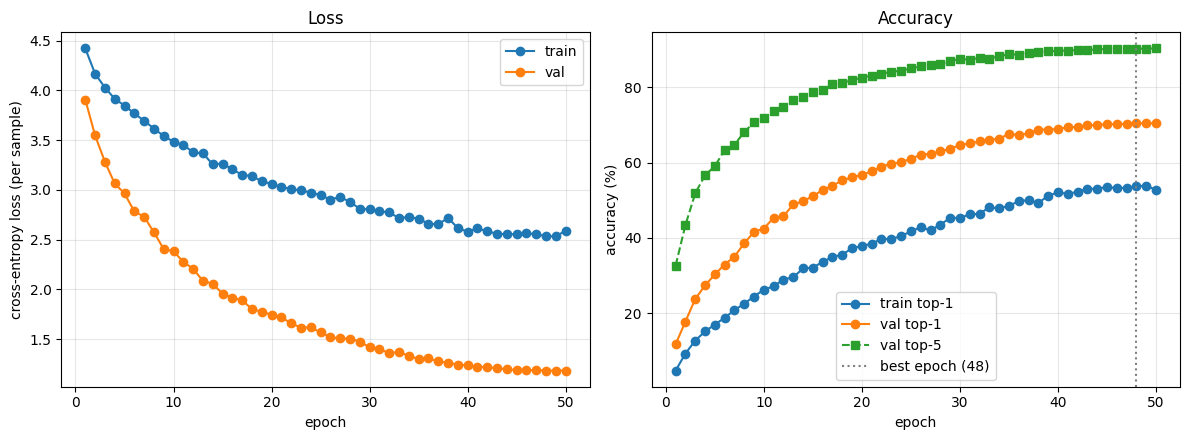

In [18]:
#Learning curves
ep = range(1, len(history["train_loss"]) + 1)
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4.5))

ax_loss.plot(ep, history["train_loss"], "o-", label="train")
ax_loss.plot(ep, history["val_loss"], "o-", label="val")
ax_loss.set(xlabel="epoch", ylabel="cross-entropy loss (per sample)", title="Loss")
ax_loss.grid(alpha=0.3)
ax_loss.legend()

ax_acc.plot(ep, history["train_acc"], "o-", label="train top-1")
ax_acc.plot(ep, history["val_acc"], "o-", label="val top-1")
ax_acc.plot(ep, history["val_top5"], "s--", label="val top-5")
ax_acc.axvline(best_epoch, color="gray", ls=":", label=f"best epoch ({best_epoch})")
ax_acc.set(xlabel="epoch", ylabel="accuracy (%)", title="Accuracy")
ax_acc.grid(alpha=0.3)
ax_acc.legend()

plt.tight_layout()
run.log({"learning_curves": wandb.Image(fig)})   # log BEFORE plt.show()
plt.show()

In [19]:
#Prediction with the best checkpoint
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded best checkpoint: epoch {ckpt['epoch']}, val acc {ckpt['val_acc']:.2f}%")

# class names: use the HF ClassLabel names if the dataset has them, else fall back to indices
label_feature = raw_val.features["label"]
class_names = (label_feature.names if hasattr(label_feature, "names")
               else [str(i) for i in range(num_classes)])


@torch.no_grad()
def predict_image(pil_img, k=5):
    """Top-k (class_name, probability) for one PIL image."""
    x = val_transform(pil_img.convert("RGB")).unsqueeze(0).to(device)   # (1, 3, 224, 224)
    probs = model(x).softmax(dim=1)[0]                                   # (100,) probabilities
    top_p, top_i = probs.topk(k)
    return [(class_names[i], p) for p, i in zip(top_p.tolist(), top_i.tolist())]


# example: one raw image from the HF val split
sample = raw_val[0]
print("true:", class_names[sample["label"]])
for name, p in predict_image(sample["image"]):
    print(f"  {name:30s} {p:.3f}")

# W&B table of 32 random val predictions (random because val is usually sorted by class)
MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

idx = torch.randperm(len(val_dataset))[:32].tolist()
images = torch.stack([val_dataset[i][0] for i in idx])     # (32, 3, 224, 224), normalized
labels = torch.stack([val_dataset[i][1] for i in idx])     # (32,)
with torch.no_grad():
    probs = model(images.to(device)).softmax(dim=1).cpu()  # (32, 100)
conf, preds = probs.max(dim=1)

table = wandb.Table(columns=["image", "true", "pred", "confidence", "correct"])
for img, y, p, c in zip(images, labels.tolist(), preds.tolist(), conf.tolist()):
    img = (img * STD + MEAN).clamp(0, 1).permute(1, 2, 0).numpy()   # undo Normalize, CHW -> HWC
    table.add_data(wandb.Image(img), class_names[y], class_names[p], round(c, 3), y == p)
run.log({"val_predictions": table})




Loaded best checkpoint: epoch 48, val acc 70.45%
true: 97
  97                             0.866
  34                             0.019
  76                             0.015
  37                             0.014
  27                             0.007


In [20]:
#Model artifact + shut down W&B
artifact = wandb.Artifact(
    name=f"vit-imagenet100-{run_name}",
    type="model",
    description=(f"ViT from scratch (patch {patch_size}, D={embedding_dim}, "
                 f"{transformer_blocks} blocks, {attention_heads} heads) on ImageNet-100"),
    metadata={
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "final_val_acc": history["val_acc"][-1],
        "num_params": num_params,
    },
)
artifact.add_file(best_path, name="best.pt")
artifact.add_file(final_path, name="final.pt")
run.log_artifact(artifact, aliases=["best"])

run.finish()   # flushes everything and marks the run as finished
drive.flush_and_unmount()   # make sure the last writes reach Drive before we delete the runtime

#  to get the model back:
# api = wandb.Api()
# art = api.artifact("maharishabh7552-dsv-global-transport-and-logistics/ViT-imagenet100/vit-imagenet100-vit-p16-d256-L6-h8-it1-adamw-cosine:best")
# art_dir = art.download()
# ckpt = torch.load(os.path.join(art_dir, "best.pt"), map_location=device)
# model.load_state_dict(ckpt["model_state_dict"])

batch/grad_norm,█▇▃▂▂▂▁▂▁▁▂▁▂▁▃▃▂▄▃▄▃▃▃▂▃▄▃▃▃▃▅▃▅▄▄▅▆▃▅▄
batch/lr,▂▃▅▅▆▇████▇▇▇▇▆▆▆▆▆▅▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
batch/train_acc,▁▂▁▂▃▃▅▂▄▅▃▅▄▃▆▃▄▆▆▃▇▄▆▆▄▅▇▄▃▇▅▆▄▇▅▅▅▇▇█
batch/train_loss,█▆▇▅▆▄▇▄▄▆▃▇▄▆▃▃▃▃▃▆▆▄▆▂▂▂▂▆▅▆▅▂▅▁▁▁▄▃▁▁
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
global_step,▁▁▁▁▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇██
train/acc,▁▂▂▂▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██████████
train/error,█▇▇▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
train/loss,█▇▇▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁
val/acc,▁▂▂▃▃▄▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇██████████████
+3,...


# Iteration 1 — changes from the baseline and why,
# Iteration 2 — changes from the Iteration 1 and why( regularization)


**Baseline:** Adam, constant lr 5e-4, no warmup/decay, no weight decay, no clipping, `randn` init for CLS/position embeddings, 20 epochs, no fixed seed.
**Goal of iteration 1:** fix *optimization* (how well the model trains). Regularization (RandAugment, label smoothing) is deliberately left for iteration 2.

## A. Optimization — the changes being tested
1. **AdamW, weight decay 0.05** — Adam + L2 (`Adam(weight_decay=...)`) divides the decay by each weight's gradient scale, so weights with large gradients barely decay. AdamW applies decay separately, shrinking every weight at the same rate (lr × wd) per step, a steady pull toward zero that the data must "earn" against. 0.05 is the DeiT value.
2. **No weight decay on biases, LayerNorm weights/biases, `cls_token`, `postion_embedding`** — LayerNorm gains should sit near 1 (decaying them weakens the signal through every layer); biases add almost no capacity to overfit; CLS and position embeddings are learned inputs, and shrinking the position embedding erases patch-position information. (54 tensors excluded, verified by printed list.)
3. **Linear warmup over 5 epochs (4,570 steps)** — at random init, gradients are large and inconsistent, and Adam's per-weight step sizes rest on very few samples. Big early steps can push attention into saturated states that are hard to escape. Warmup ramps lr from ~0 to the 5e-4 peak.
4. **Cosine decay to 1e-6, stepped every batch** — each batch gradient is the true gradient plus noise; at a high lr that noise keeps the weights bouncing around the bottom of the loss valley. Decaying the lr lets them settle. Stepping per batch (914/epoch) gives a smooth curve instead of a 50-step staircase.
5. **Gradient clipping at global norm 1.0** — rescales the full gradient vector to length ≤ 1 before the optimizer step, so no single batch can move the weights too far. Targets the one-batch loss spikes seen in the baseline. Standard ViT setting.
6. **Epochs 20 → 50** — baseline val accuracy was still rising at epoch 18–20; ViTs trained from scratch need long training because they must learn locality from data rather than having it built in like CNNs.

## B. Initialization
7. **`trunc_normal_(std=0.02)` for `cls_token` and `postion_embedding`** (was `torch.randn`, std 1) — std-1 position embeddings are large compared with the patch embeddings, so at init they dominate the token inputs. Small init is the standard ViT choice and gives a more stable start.

## C. Data pipeline
8. **`drop_last=True` on the train loader only** — the last batch of an epoch can be tiny, giving extreme loss/accuracy values and a full-size Adam step from a handful of images. Dropping it costs ≤ 127 images/epoch (a different set each epoch due to shuffling). Val keeps every image.
9. **`persistent_workers=True` on both loaders** — by default worker processes restart every epoch and every validation pass, leaving the GPU idle while they refill. Keeping them alive removes that stall. No effect on results.

## D. Speed (no effect on results beyond floating-point differences)
10. **`need_weights=False` in `nn.MultiheadAttention`** — the default builds and returns the full (B, heads, T, T) attention matrix (~159 MB per block at B = 128) even though the code discards it. Turning it off lets PyTorch use a fused attention kernel: same output, less memory, faster.
11. **TF32 matmuls (`torch.set_float32_matmul_precision("high")`)** — FP32 matrix multiplications run on the A100's tensor cores with a 10-bit mantissa internally; tensors are still stored in FP32. Large speedup, negligible accuracy effect. *Not quantization and not mixed precision.*

## E. Reproducibility
12. **Fixed seed (42) for Python, NumPy, PyTorch, CUDA, called right before building the model** — iterations 1 and 2 start from identical weights, so their difference reflects the recipe, not initialization luck.
13. **Seeded `torch.Generator` for the train loader** — same shuffle order and same per-worker augmentation randomness across runs.

## F. Infrastructure (protects the run; no effect on results)
14. **Checkpoints in a per-run Google Drive folder** (`best.pt`, `last.pt`, `final.pt`) — Colab's `/content` is wiped on disconnect, and per-run folders mean no run overwrites another.
15. **`last.pt` every epoch with model, optimizer, scheduler, epoch, global_step, best-so-far and history; written to a temp file then renamed** — enough state to resume exactly where training stopped; the rename means a disconnect mid-save can't leave a corrupted file.
16. **Resume cell + loop from `start_epoch`** — after a disconnect, rerunning all cells continues from the last completed epoch instead of restarting. Verified with an interrupt + restart test.
17. **Fixed W&B run id with `resume="allow"`** — a reconnect continues the same W&B run, so curves stay in one place.
18. **Per-run artifact name (`vit-imagenet100-<run_name>`) and `drive.flush_and_unmount()`** — each run's model is a separate artifact; the flush makes sure final Drive writes are synced before the runtime is deleted.
19. **Logging `batch/grad_norm` (pre-clip norm) and all new settings in the W&B config** — shows how often and how hard clipping acts, and makes every run's recipe inspectable.

## G. Regularization — the changes tested in iteration 2
20. **RandAugment (2 ops, magnitude 9)** — each training image gets 2 random operations (rotation, color, contrast, shear, …), so the model can't memorize exact pixel content.
21. **Label smoothing 0.1** — training targets become 0.901 on the true class and 0.001 on each other class, discouraging absolute certainty.
22. **CutMix (α = 1.0, applied to 50% of batches)** — pastes a rectangle from another image in the batch and mixes labels by area, forcing recognition from partial evidence. Applied to half the batches (not every batch as in DeiT) because the run is 50 epochs, not 300.
- Validation uses plain cross-entropy, so val metrics compare directly with iteration 1. Train loss/accuracy do **not** compare (soft targets, harder images).
23. **Early stopping** being `skipped` deliberatley in order to have valid comparison between iter1 and iter2
24. Favouring **cutmix over dropout** as modern Vit Practice.
25. **Leaving out drop path** as stochastic depth seems to help in deeper models , here the depth is only 6 blocks.


## Held constant (same as baseline)
1. Architecture (patch 16, D = 256, 6 blocks, 8 heads, MLP hidden 512, ~3.44M params) · batch size 128 · peak lr 5e-4 (DeiT's base rate, *not* rescaled for batch 128 — DeiT's rule would give 1.25e-4; kept because the baseline trained stably at 5e-4) · augmentation (RandomResizedCrop + horizontal flip) · plain cross-entropy loss · no dropout.

2. everything from iteration 1


## How to read the comparison
- **Baseline → iteration 1 is not a clean comparison:** it changes the optimization recipe *and* training length (20 → 50 epochs) *and* adds TF32. Any gain is "better recipe + longer training", not AdamW alone.
- **Iteration 1 → iteration 2 will be clean:** same seed, epochs and everything else; only regularization changes.
- **Single seed per configuration (compute budget):** differences under ~2 accuracy points are treated as inconclusive.

In [21]:
best_valtop1_acc=np.max(history['val_acc'])
best_valtop1_acc_epoch=np.argmax(history['val_acc'])+1

best_valtop5_acc=np.max(history['val_top5'])
best_valtop5_acc_epoch=np.argmax(history['val_top5'])+1

mean_valacc_last_epochs=np.mean(history['val_acc'][-3:])

val_gap_epoch50=history['train_acc'][-1]-history['val_acc'][-1]

va = np.array(history["val_acc"])
delta = 1.0 # percentage points
plateau_epoch = int(np.argmax(va >= va.max() - delta)) + 1

def acc_se(acc_pct, n):
    p = acc_pct / 100                          # accuracy as a fraction
    return 100 * np.sqrt(p * (1 - p) / n)      # sqrt(p(1-p)/n), back to % points

n_val = len(val_dataset)                       # 13,000 validation images
se_top1 = acc_se(best_valtop1_acc, n_val)
se_top5 = acc_se(best_valtop5_acc, n_val)




In [22]:
print(f'Best validatiion acc :{ best_valtop1_acc} at epoch {best_valtop1_acc_epoch}\n'
      f'Best top5 val acc:{best_valtop5_acc} at epoch {best_valtop5_acc_epoch}\n'
      f'mean acc last 3 epochs: {mean_valacc_last_epochs}\n'
      f'val gap at last epoch : {val_gap_epoch50}\n'
      f'val acc plateau at epoch {plateau_epoch}\n'
      f'se top1 : {se_top1}\n'
      f'se top5 : {se_top5}')


Best validatiion acc :70.45384615384616 at epoch 48
Best top5 val acc:90.3076923076923 at epoch 50
mean acc last 3 epochs: 70.43846153846154
val gap at last epoch : -17.69639370476351
val acc plateau at epoch 42
se top1 : 0.4001576782983652
se top5 : 0.2594802409593814


## Iteration 1 — results (50 epochs, A100, seed 42)
- Best val top-1: **66.53%** (epoch 49); mean of last 3 epochs: 66.49%
- Best val top-5: **87.88%** (epoch 43)
- Train − val accuracy gap at epoch 50: 16.7 points (train ≈ 83%)
- Val accuracy plateau: within 1 point of best from epoch 36 (rule: first epoch with val_acc ≥ best − 1)
- Train/val loss crossed at epoch ~19; val loss flat at ~1.3 from epoch ~30 while train loss kept falling
- Val set: 13,000 images (130/class) → measurement std. error ≈ 0.4 points; single seed, so differences < ~2 points treated as inconclusive
- **Takeaway:** optimization recipe + longer training lifted accuracy well above the baseline, but the model overfits in the second half → iteration 2 adds regularization.
## Iteration 2 — results (50 epochs, L4, seed 42)
- Best val top-1: **70.45%** (epoch 48); mean of last 3 epochs: 70.44%
- Best val top-5: **90.31%** (epoch 50)
- Val accuracy plateau: within 1 point of best from epoch 42 (iteration 1: epoch 36)
- Std. error: 0.40 (top-1), 0.26 (top-5); single seed

## Iteration 1 → Iteration 2 (clean comparison: only regularization changed)
- Top-1: 66.53% → 70.45% (**+3.9 points**, ~7× the std. error of the difference) → regularization helped
- Top-5: 87.88% → 90.31% (+2.4 points; top-5 error 12.1% → 9.7%, a 20% relative reduction)
- Plateau moved later (36 → 42) and best epochs are at the very end (48, 50) → the regularized model was still improving; longer training is the next lever
- Train accuracy/loss are not comparable across the two runs (augmented + mixed images, smoothed targets) — comparison uses validation metrics only

In [24]:
from torch.utils.data import Subset

#Clean training subset: same size as val, val preprocessing.
g_eval = torch.Generator().manual_seed(0)
idx = torch.randperm(len(raw_train), generator=g_eval)[:len(val_dataset)].tolist()
train_clean = Subset(HuggingFaceImageNetSubset(raw_train, transform=val_transform), idx)
train_clean_loader = DataLoader(train_clean, batch_size=batch_size, shuffle=False,
                                num_workers=8, pin_memory=True)

#Load a checkpoint into a fresh model ( and renames iteration-1 MLP keys to the new layout ( dropout added in iter 2))
def load_model(path):
    sd = torch.load(path, map_location=device)["model_state_dict"]
    if any(".mlp.2.weight" in k for k in sd):                 # iteration-1 checkpoint
        sd = {k.replace(".mlp.2.", ".mlp.3."): v for k, v in sd.items()}
    m = VisionTransformer().to(device)
    m.load_state_dict(sd)
    return m

#Seen (clean train) vs unseen (val), same model, same loss
paths = {
    "iteration 1": "/content/drive/MyDrive/vit-imagenet100/vit-p16-d256-L6-h8-it1-adamw-cosine/best.pt",
    "iteration 2": "/content/drive/MyDrive/vit-imagenet100/vit-p16-d256-L6-h8-it2-ra-ls-cm/best.pt",
}
for name, path in paths.items():
    m = load_model(path)
    tr_loss, tr_acc, _ = evaluate(m, train_clean_loader)
    va_loss, va_acc, _ = evaluate(m, val_loader)
    print(f"{name}: clean-train acc {tr_acc:.2f}% vs val {va_acc:.2f}% -> gap {tr_acc - va_acc:.2f} pts | "
          f"loss {tr_loss:.3f} vs {va_loss:.3f}")

iteration 1: clean-train acc 94.10% vs val 66.52% -> gap 27.58 pts | loss 0.228 vs 1.340
iteration 2: clean-train acc 78.08% vs val 70.45% -> gap 7.63 pts | loss 0.906 vs 1.184


## Generalization gap — measured directly (best checkpoints, 13,000 clean train images vs 13,000 val, val preprocessing, plain CE)
| | Clean-train acc | Val acc | Gap | Clean-train loss | Val loss |
|---|---|---|---|---|---|
| Iteration 1 | 94.10% | 66.52% | 27.6 pts | 0.228 | 1.340 |
| Iteration 2 | 78.08% | 70.45% | 7.6 pts | 0.906 | 1.184 |

- Iteration 1 memorized heavily: the logged +16.7-pt gap (augmented train images) understated the true 27.6-pt gap.
- Regularization (RandAugment + label smoothing + CutMix) cut the gap by ~72% (27.6 → 7.6 pts) while raising val top-1 by 3.9 pts: less fit on seen data, better generalization.
- With the gap now small and clean-train accuracy at 78%, the next lever is more training (epochs / model size), not more regularization.

# Bias–variance view of the ViT runs


## Practical version for classification
With right/wrong error the split isn't exactly additive, so we use two measurable proxies:
- **Bias proxy = training error**: how badly the model fits images it has seen. (Avoidable bias = training error − irreducible error; the irreducible error is unknown, so training error is an upper bound.)
- **Variance proxy = val error − training error**: the **generalization gap**.
- By construction: val error = training error + gap.

## Measurement
Logged train metrics use augmented images and smoothed/mixed targets, so they can't be used here. Instead, for each best checkpoint: 13,000 random training images (fixed seed, same for both runs) vs the 13,000 val images, both with **val preprocessing**, no mixing, plain cross-entropy, eval mode. Same model, pipeline and loss; only **seen vs unseen** differs. Errors are used, not losses (label smoothing changes loss values).

##  Results
| Run | Train error (bias proxy) | Gap (variance proxy) | Val error | Val top-1 |
|---|---|---|---|---|
| Iteration 1 | 5.9% | 27.6 pts | 33.5% | 66.5% |
| Iteration 2 | 21.9% | 7.6 pts | 29.5% | 70.5% |
| Change | +16.0 pts | −20.0 pts | −3.9 pts | +3.9 pts |

Standard error ≈ 0.2–0.4 pts per error, ≈ 0.5 pts per gap; all changes are far outside noise.

##  Reading it
- **Iteration 1: low bias, high variance (overfitting).** 94% right on its own training images, 27.6 pts worse on new ones; ~82% of its val error is gap.
- **Iteration 2: bias up, variance sharply down.** Bias proxy +16, variance proxy −20, so total error −4. Now ~74% of val error is training error: **bias-dominated**.
- **Mechanism:** RandAugment, CutMix and label smoothing make the training task harder and remove memorizable shortcuts, so the model can't memorize (variance ↓) but fits the training set less (bias ↑). Augmentation acts like a larger, more varied dataset.
- **The trade paid off** because variance fell more than bias rose. Regularization only helps while the gap is the larger term.

## 6. Which knob moved which term
- **Reduce variance (bias rises):** augmentation (RandAugment, CutMix, Mixup), label smoothing, weight decay, dropout / drop path, early stopping.
- **Reduce variance without a bias cost:** more real training data.
- **Reduce bias (variance tends to rise):** more epochs, larger model (D, L, MLP ratio 4), better optimization, less regularization.
- Iteration 1's changes were mostly bias-side (better optimization, 2.5× longer training), hence its very low training error and very large gap.

## 7. Next step (TODO)
Iteration 2 is bias-dominated (21.9 vs 7.6) and still improving at the end (plateau from epoch 42; best epochs 48 and 50), so the next lever is **bias reduction**: longer training or a larger model, while keeping the gap small. More regularization would mostly raise bias further.

## 8. Caveats
- The proxies aren't the formal decomposition; for classification, bias and variance don't add exactly.
- The irreducible error is unknown, so part of the 21.9% training error may be unavoidable.
- Formal variance is the spread across training sets and seeds; the gap measures a related quantity. Seed-to-seed spread wasn't measured (single seed).
- Iteration 1 ran on an A100, iteration 2 on an L4 (tiny floating-point differences only).

In [25]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
#Load the test files (~726 MB), not the whole 17 GB dataset
raw_test = load_dataset("ilee0022/ImageNet100", split="test")
test_dataset = HuggingFaceImageNetSubset(raw_test, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=8, pin_memory=True)

#Sanity checks
print("test images:", len(raw_test))                                   # 5000
print("per-class counts:", set(np.bincount(raw_test["label"])))       #{50}
same_labels = set(zip(raw_test["label"], raw_test["text"])) <= set(zip(raw_train["label"], raw_train["text"]))
print("label ids mean the same classes as in train:", same_labels)     # must be True

# Evaluate the chosen model once
m = load_model("/content/drive/MyDrive/vit-imagenet100/vit-p16-d256-L6-h8-it2-ra-ls-cm/best.pt")
test_loss, test_acc, test_top5 = evaluate(m, test_loader)
se_test = acc_se(test_acc, len(raw_test))
print(f"TEST  top-1 {test_acc:.2f}% ± {se_test:.2f} (SE) | top-5 {test_top5:.2f}% | loss {test_loss:.3f}")

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

test images: 5000
per-class counts: {np.int64(50)}
label ids mean the same classes as in train: True
TEST  top-1 65.84% ± 0.67 (SE) | top-5 87.38% | loss 1.362


## Final test evaluation (iteration 2, best.pt epoch 48 — selected on validation, test used once)
- Test split: 5,000 images (50/class); label ids verified identical to train
- **Test top-1: 65.84% ± 0.67 (SE)**, top-5: 87.38%, loss 1.362
- Validation: 70.45% top-1 / 90.31% top-5 → test is 4.6 / 2.9 pts lower (~6 SE, not noise; not explained by best-epoch selection, since best ≈ last-3 mean)
- Likely cause: validation is a random 10% slice of ImageNet's *training* pool (shares near-duplicate / same-source images with train), while test is most likely ImageNet's separately collected official validation images → validation overstates generalization; test is the honest number
- Run comparisons on validation remain valid (same images for all runs); absolute numbers should be quoted on test
- True generalization gap vs test: 78.08% (clean train) − 65.84% = 12.2 pts (vs 7.6 measured on validation)

In [29]:
runs = {
    "iteration 1": ("/content/drive/MyDrive/vit-imagenet100/vit-p16-d256-L6-h8-it1-adamw-cosine/best.pt", 66.53, 87.88),
    "iteration 2": ("/content/drive/MyDrive/vit-imagenet100/vit-p16-d256-L6-h8-it2-ra-ls-cm/best.pt",     70.45, 90.31),
}   # name: (checkpoint, best val top-1, best val top-5)

for name, (path, val1, val5) in runs.items():
    m = load_model(path)
    test_loss, test1, test5 = evaluate(m, test_loader)
    print(f"{name}: test top-1 {test1:.2f}% ± {acc_se(test1, len(raw_test)):.2f} | top-5 {test5:.2f}% | "
          f"loss {test_loss:.3f} | val→test drop: top-1 {val1 - test1:.2f}, top-5 {val5 - test5:.2f}")

iteration 1: test top-1 60.82% ± 0.69 | top-5 83.82% | loss 1.652 | val→test drop: top-1 5.71, top-5 4.06
iteration 2: test top-1 65.84% ± 0.67 | top-5 87.38% | loss 1.362 | val→test drop: top-1 4.61, top-5 2.93


## Final test evaluation (test split used once; checkpoints selected on validation)

**Test set:** 5,000 images (50/class), label ids verified identical to train. Most likely ImageNet's official validation images for these 100 classes, collected separately from the training pool. Our validation set (13,000) is a random 10% slice of ImageNet's *training* images.

| Run | Val top-1 | **Test top-1** (± SE) | Val→test drop | Val top-5 | Test top-5 | Val→test drop | Test loss |
|---|---|---|---|---|---|---|---|
| Iteration 1 | 66.53% | **60.82% ± 0.69** | 5.71 pts | 87.88% | 83.82% | 4.06 pts | 1.652 |
| Iteration 2 (final) | 70.45% | **65.84% ± 0.67** | 4.61 pts | 90.31% | 87.38% | 2.93 pts | 1.362 |

**Final model: iteration 2 → test top-1 65.84% ± 0.67, top-5 87.38%.**

**Regularization gain holds on untouched data:** test top-1 +5.0 pts (60.82 → 65.84; SE of the difference ≈ 0.96, so ~5 SE), test top-5 +3.6 pts. Relative error reduction: top-1 13% (39.2% → 34.2%), top-5 22% (16.2% → 12.6%). The test gain is slightly larger than the validation gain (+3.9 pts).

**Validation is optimistic by ~4.6 pts, for both models.** Both drop several points from validation to test. The drops differ by only 1.1 pts (top-1 and top-5 alike), about 1 SE (SE of the difference ≈ 1.1, conservative), so the gap is mostly a property of the two sets, not of how much a model memorized. The difference points in the direction the memorization explanation predicts (the model that memorized more drops more) but is too small to confirm. Likely source: validation comes from the same pool as training, while test was collected separately. This check cannot separate near-duplicates that help any model from a general difference in difficulty between the sets.

**Generalization gap against test** (clean-train accuracy − test accuracy): iteration 1: 33.3 pts, iteration 2: 12.2 pts → regularization closed 21 pts of the gap (validation-based estimates: 27.6 and 7.6 pts, both understated).

**Takeaways**
- Absolute performance is reported on test; validation is used only to compare runs (same images for every run, so comparisons remain valid).
- Regularization's benefit is confirmed on untouched data: +5.0 pts top-1, 21 pts smaller generalization gap.
- A validation split drawn from the training pool overstated accuracy by ~4.6 pts for both models. For future projects: validate on data collected separately from the training data when possible.
- The test set is now closed: any future iteration is compared on validation only.